# Обучение t-SNE

## Описание данных

Датасет содержит информацию, собранную с помощью носимых трекеров, фиксирующих состояние человеческого организма во время сна. Для каждой записи представлены физиологические показатели пользователя, а также некоторые демографические характеристики.

В датасете 12 признаков

Снижение размерности полезно при работе с этими данными, поскольку некоторые показатели описывают пересекающиеся аспекты физиологии. Кроме того, в 12-мерном пространстве человек на глаз не сможет провести визуальный анализ. Без него будет сложнее определить, какие режимы сна встречаются в данных и насколько они похожи друг на друга.

Целевая переменная **stress-level**  не включена в датасет, поскольку для обучения t-SNE не нужна, достаточно входных признаков. 



## Загрузка данных

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

In [2]:
# Загружаем датасет
df = pd.read_csv("https://code.s3.yandex.net/datasets/ds_s18t5_sleep.csv")

# Фиксируем список признаков для работы
feature_cols = [
    "age",
    "marital-status",
    "gender",
    "bmi",
    "snoring-rate",
    "respiration-rate",
    "body-temperature",
    "limb-movement",
    "blood-oxygen",
    "eye-movement",
    "sleeping-hours",
    "heart-rate",
]

# Создаём копию, чтобы не менять исходный df
X = df[feature_cols].copy()

# Проверяем размер матрицы признаков: число объектов и признаков
print("X shape:", X.shape)

X shape: (5000, 12)


In [3]:
# Приводим все данные к числовому формату
# Если в файле все признаки уже содержат данные типа 0/1 и float, этот шаг ничего не испортит
# errors="coerce" превращает нечисловые значения в NaN
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

# Заполняем пропуски медианой по каждому столбцу
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

# Масштабируем признаки: после StandardScaler в каждом столбце будет среднее ~0 и std ~1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Проверяем размер итоговой матрицы, которую будем передавать t-SNE
print("X_scaled shape:", X_scaled.shape)

X_scaled shape: (5000, 12)


## Математические преобразования t-SNE

На вход подаётся матрица признаков:

$$X \in \mathbb{R}^{n \times d}$$

На выходе матрица координат:

$$\begin{cases} Y \in \mathbb{R}^{n \times 2}, & \text{если график в 2D} \\ Y \in \mathbb{R}^{n \times 3}, & \text{если график в 3D} \end{cases}$$

## Обучение t-SNE

In [ ]:
# 1. Создаём модель t-SNE и фиксируем ключевые параметры проекции
tsne = TSNE(
    n_components=2, # выбираем 2D-координаты
    perplexity=30, # масштаб локального окружения
    init="pca", # стартовая инициализация через PCA
    random_state=42, # фиксируем случайность для воспроизводимости
    learning_rate="auto"
)
# 2. Запускаем оптимизацию и получаем матрицу координат (n_samples, 2)
X_tsne = tsne.fit_transform(X_scaled)

# 3. Упаковываем координаты в таблицу для дальнейшей визуализации
tsne_df = pd.DataFrame(X_tsne, columns=["tsne_1", "tsne_2"])
tsne_df.head() # координаты объектов на плоскости

,tsne_1,tsne_2
0,-19.252104,-19.099648
1,-42.944550,-14.902308
2,-23.296902,38.824799
3,11.057096,-5.957903
4,-25.507927,-10.623979


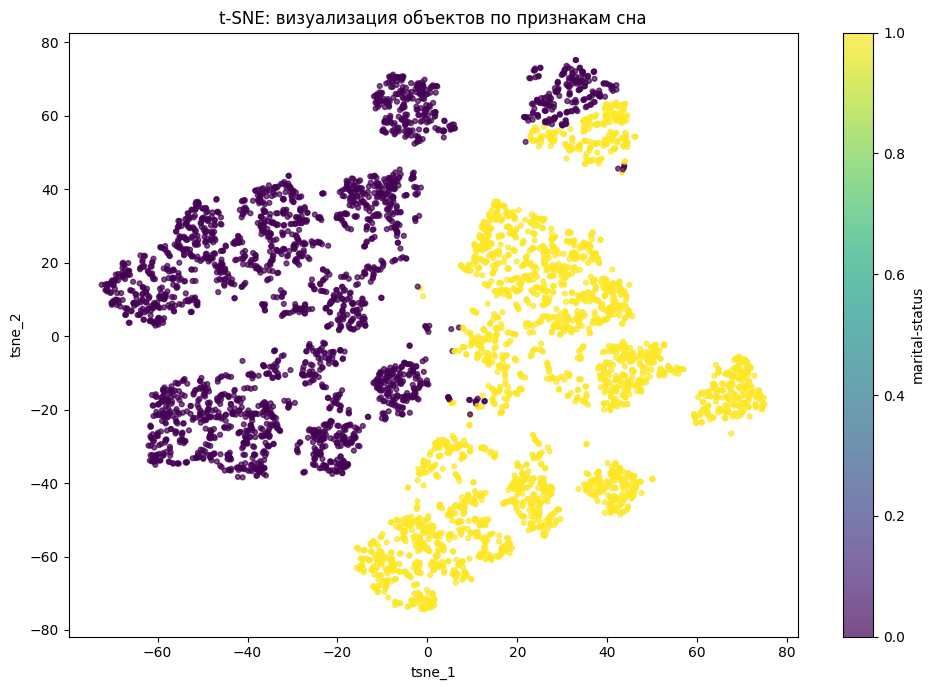

In [7]:
# 3. Отдельно сохраняем признак для раскраски и добавляем в таблицу
color_values = df["marital-status"].values
tsne_df["marital-status"] = color_values

# 4. Строим диаграмму рассеяния
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    tsne_df["tsne_1"],
    tsne_df["tsne_2"],
    c=tsne_df["marital-status"],
    s=12,
    alpha=0.7,
)

plt.title("t-SNE: визуализация объектов по признакам сна")
plt.xlabel("tsne_1")
plt.ylabel("tsne_2")
plt.colorbar(scatter, label="marital-status")

plt.tight_layout()
plt.show()

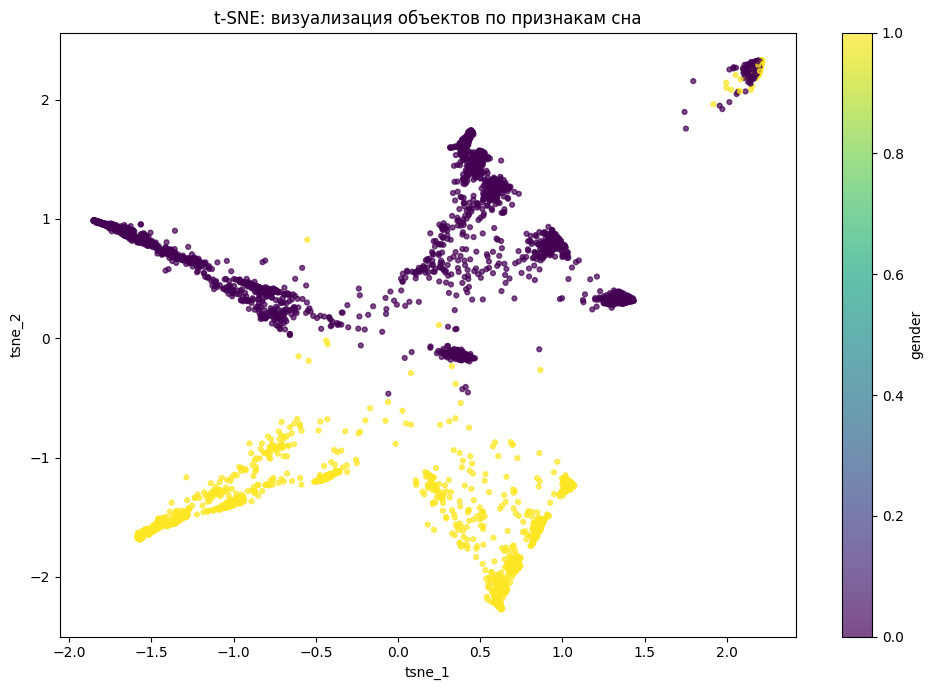

,tsne_1,tsne_2,gender
0,-0.890015,-1.275885,1
1,-1.478143,-1.584512,1
2,-1.150673,0.592386,0
3,0.027041,0.475705,0
4,-0.780843,-0.937493,1


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Подготовьте импорты
from sklearn.preprocessing import StandardScaler # Масштабирование
from sklearn.manifold import TSNE # t-SNE

df = pd.read_csv("https://code.s3.yandex.net/datasets/ds_s18t5_sleep.csv")

# Формируем матрицу признаков X из 12 столбцов
feature_cols = [
    "age",
    "marital-status",
    "gender",
    "bmi",
    "snoring-rate",
    "respiration-rate",
    "body-temperature",
    "limb-movement",
    "blood-oxygen",
    "eye-movement",
    "sleeping-hours",
    "heart-rate",
]

# Копируем признаки
X = df[feature_cols].copy()

# Масштабируем признаки
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Отдельно сохраняем признак для окрашивания точек
color_values = df["gender"].values

# Обучите t-SNE и получите 2D-координаты объектов
tsne = TSNE(
    n_components=2,
    perplexity=30,       
    learning_rate=200,     
    random_state=42,      
    init="pca",              
    max_iter=250           
)

X_tsne = tsne.fit_transform(X_scaled)

# Сложите координаты в таблицу
tsne_df = pd.DataFrame(X_tsne, columns=["tsne_1", "tsne_2"])

# Добавьте колонку для цвета
tsne_df["gender"] = color_values

# Постройте диаграмму рассеяния
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    tsne_df["tsne_1"],
    tsne_df["tsne_2"],
    c=tsne_df["gender"],
    s=12,
    alpha=0.7
)

plt.title("t-SNE: визуализация объектов по признакам сна")
plt.xlabel("tsne_1")
plt.ylabel("tsne_2")

plt.colorbar(scatter, label="gender")

plt.tight_layout()
plt.show()

tsne_df.head()

